# Creating Housing Zones

---------------------------------------------------------------------------------------

### Import packages

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import numpy as np
from shapely.geometry import Point

### Load data

In [ ]:
migrations_flows = pd.read_csv('/Users/user1/Documents/housing_zones/flow_data/migration_flow_la_2023.csv')
commuting_flows = pd.read_csv('/Users/user1/Documents/housing_zones/flow_data/commuting_flow_la_2023.csv')

In [4]:
la_2023_shape_file = '/Users/user1/Downloads/Local_Authority_Districts_May_2023_UK_BFE_V2_5074811840009224353'

In [5]:
gdf_la_2023 = gpd.read_file(la_2023_shape_file)

In [6]:
#Only keep LAD23CD in Beginning with E and W
gdf_la_2023 = gdf_la_2023[gdf_la_2023['LAD23CD'].str.startswith(('E', 'W'))]

In [7]:
# Inspect the data structure
print("Migration flows shape:", migrations_flows.shape)
print("Migration flows columns:", list(migrations_flows.columns))
print("\nCommuting flows shape:", commuting_flows.shape)
print("Commuting flows columns:", list(commuting_flows.columns))
print("\nGeoDataFrame shape:", gdf_la_2023.shape)
print("GeoDataFrame columns:", list(gdf_la_2023.columns[:10]))

Migration flows shape: (84762, 3)
Migration flows columns: ['outla', 'inla', 'moves']

Commuting flows shape: (80932, 3)
Commuting flows columns: ['RES_LAD23CD', 'WORK_LAD23CD', 'flow']

GeoDataFrame shape: (318, 9)
GeoDataFrame columns: ['LAD23CD', 'LAD23NM', 'LAD23NMW', 'BNG_E', 'BNG_N', 'LONG', 'LAT', 'GlobalID', 'geometry']


In [8]:
# Standardize column names for consistency
migrations_flows_clean = migrations_flows.rename(columns={
    'outla': 'origin',
    'inla': 'destination',
    'moves': 'flow'
})

commuting_flows_clean = commuting_flows.rename(columns={
    'RES_LAD23CD': 'origin',
    'WORK_LAD23CD': 'destination'
})

print("✓ Standardized column names")
print(f"  Migration flows: {list(migrations_flows_clean.columns)}")
print(f"  Commuting flows: {list(commuting_flows_clean.columns)}")

✓ Standardized column names
  Migration flows: ['origin', 'destination', 'flow']
  Commuting flows: ['origin', 'destination', 'flow']


###  Create flow matrices

In [9]:
# Create flow matrices for easier lookup
def create_flow_dict(flow_df):  
    """Convert flow DataFrame to nested dict: {origin: {destination: flow}}"""
    flow_dict = {}  # Initialise empty dictionary to store the nested flow structure
    for _, row in flow_df.iterrows(): #(ignore index with _)
        origin = row['origin']  # Extract the origin LA code from current row
        dest = row['destination']  # Extract the destination LA code from current row
        flow = row['flow']  # Extract the flow count (number of people/commuters) from current row
        
        if origin not in flow_dict: # Check if origin LA is already a key in the dictionary
            flow_dict[origin] = {} # If not, initialise it with an empty dictionary, if so we can add destinations to it
        flow_dict[origin][dest] = flow  # Set the flow count for the origin-destination pair
    
    return flow_dict

commuting_flows_la = create_flow_dict(commuting_flows_clean) 
migration_flows_la = create_flow_dict(migrations_flows_clean)

print(" Created flow lookup dictionaries")
print(f"  Commuting: {len(commuting_flows_la)} origin LAs")
print(f"  Migration: {len(migration_flows_la)} origin LAs")

 Created flow lookup dictionaries
  Commuting: 318 origin LAs
  Migration: 318 origin LAs


### Build graph for neighboring LA

In [10]:
# Build neighborhood graph, find which LAs are adjacent


def build_neighbors_dict(gdf):
    """Find neighboring LAs based on shared boundaries"""
    neighbors = {}
    
    for idx1, row1 in gdf.iterrows(): # Loop through each row in the GeoDataFrame
        la1 = row1['LAD23CD']
        neighbors[la1] = set() # Initialise an empty set to store neighbors
        
        for idx2, row2 in gdf.iterrows():
            if idx1 != idx2: # Avoid self-comparison
                la2 = row2['LAD23CD']
                # Check if geometries touch or intersect
                if row1.geometry.touches(row2.geometry) or row1.geometry.intersects(row2.geometry):
                    neighbors[la1].add(la2) # Add la2 as a neighbor of la1
    
    return neighbors

print("Building neighborhood graph...")
neighbors = build_neighbors_dict(gdf_la_2023)
print(f"Built neighbors dictionary for {len(neighbors)} LAs")

Building neighborhood graph...
Built neighbors dictionary for 318 LAs


### Self-containment

In [11]:
# Core algorithm functions

def self_containment(region_las, flows_dict):
    """Calculate self-containment for a set of LAs"""
    #initialise counters
    internal_flow = 0 
    total_flow = 0
    
    for origin in region_las:
        if origin not in flows_dict:
            continue
        for dest, flow in flows_dict[origin].items(): # Iterate over all destinations and their flows from the origin
            total_flow += flow
            if dest in region_las:
                # Add this flow to the total (counts ALL outbound flows)
                internal_flow += flow # Add this flow to the internal flow count if destination is within the region
    
    if total_flow == 0: #handle division by zero
        return 0 #region no flows
    return internal_flow / total_flow #

def bidirectional_flows(region_a, region_b, flows_dict):
    """Calculate sum of flows in both directions between two regions"""
    flow = 0
    
    # Flows from A to B
    for origin in region_a:
        if origin not in flows_dict: 
            continue  # No data for this origin, move to next
        for dest in region_b:   # Loop through each LA in region B (potential destinations)
            # Check if there's actually a flow from this origin to this destination
            # flows_dict[origin] is a dict like {'E08000002': 500, 'E08000005': 300}
            if dest in flows_dict[origin]: 
                # Add this A→B flow to our total
                flow += flows_dict[origin][dest]
    
    # Flows from B to A
    #Now reverse, Region B origins, Region A destinations
    for origin in region_b:
        if origin not in flows_dict:
            continue
        for dest in region_a:
            if dest in flows_dict[origin]:
                flow += flows_dict[origin][dest]
    
    # Return the sum of flows in both directions
    return flow

print(" Defined helper functions")

 Defined helper functions


### Implementation 

### Step 1 communting closure

In [12]:
COMMUTING_THRESHOLD = 0.725  # 72.5% from paper
MIGRATION_THRESHOLD = 0.55   # 55% from paper

print("=" * 80)
print("STEP 1: Building commuting-based areas")
print(f"Target: {COMMUTING_THRESHOLD:.1%} commuting closure")
print("=" * 80)

# Initialise, each LA starts as its own region
commuting_regions = {la: {la} for la in gdf_la_2023['LAD23CD']}

sc_cache_commuting = {la: self_containment({la}, commuting_flows_la) #store self-containment scores
                      for la in commuting_regions.keys()}

iteration = 0 
max_iterations = 2000 #set a max to avoid infinite loops

while iteration < max_iterations:
    iteration += 1 
    
    # Find regions below threshold
    failing_regions = [region_id for region_id, sc in sc_cache_commuting.items() 
                      if sc < COMMUTING_THRESHOLD]
    # If cache has for example:
    # {'E08000001': 0.12, 'R_5': 0.68, 'R_12': 0.80}
    # Then failing_regions = ['E08000001', 'R_5']
    # (R_12 passes with 80%, excluded from list)
    
    if not failing_regions:
        print(f"\n All regions meet {COMMUTING_THRESHOLD:.1%} threshold after {iteration-1} iterations")
        break
    
    if iteration % 10 == 0: #progress update every 10 iterations
        print(f"Iteration {iteration}: {len(commuting_regions)} regions, {len(failing_regions)} below threshold")
    
    # Find best pair to merge
    best_pair_id = None
    best_flow = 0 # Initialise best flow found so far, to compare merges
    
    for region_id in failing_regions:
        r = commuting_regions[region_id] # failing region, get the set of LAs for this region
        
        # Get neighboring LAs
        r_neighbors = set() # Initialise empty set for neighbors
        for la in r:
            if la in neighbors: # Check if LA has neighbors
                r_neighbors.update(neighbors[la]) # Add neighbors to the set
        r_neighbors = r_neighbors - r # Exclude LAs already in region
        
        # Find which regions these neighbors belong to
        for other_id, s in commuting_regions.items(): 
            if other_id == region_id: # Avoid self-comparison
                continue
            if not r_neighbors.intersection(s): # No shared neighbors, skip
                continue
            
            # Calculate bidirectional commuting flow
            flow = bidirectional_flows(r, s, commuting_flows_la) # Get total flow between the two regions
            if flow > best_flow: # If this flow is better than the best found so far
                best_flow = flow # Update best flow
                best_pair_id = (region_id, other_id) # Store the best pair IDs
    
    if best_pair_id is None: # No valid merges found, for example all neighbors already merged 
        print(f"\n No valid merges found. Stopping with {len(failing_regions)} regions below threshold")
        break
    
    # Merge the best pair
    i, j = best_pair_id # Unpack the best pair IDs  
    merged = commuting_regions[i] | commuting_regions[j] # Merge the two regions (set union)
    
    # delete old regions so we can add the merged one
    del commuting_regions[i] 
    del commuting_regions[j]
    del sc_cache_commuting[i]
    del sc_cache_commuting[j]
    
    new_id = f"R_{iteration}" # New region ID based on iteration, e.g. R_1, R_2 etc
    commuting_regions[new_id] = merged # Add merged region to the dict 
    sc_cache_commuting[new_id] = self_containment(merged, commuting_flows_la)  # Calculate and store new self-containment score

print(f"\n Created {len(commuting_regions)} commuting-based regions")

STEP 1: Building commuting-based areas
Target: 72.5% commuting closure
Iteration 10: 309 regions, 277 below threshold
Iteration 20: 299 regions, 265 below threshold
Iteration 30: 289 regions, 254 below threshold
Iteration 40: 279 regions, 243 below threshold
Iteration 50: 269 regions, 232 below threshold
Iteration 60: 259 regions, 222 below threshold
Iteration 70: 249 regions, 212 below threshold
Iteration 80: 239 regions, 202 below threshold
Iteration 90: 229 regions, 190 below threshold
Iteration 100: 219 regions, 180 below threshold
Iteration 110: 209 regions, 170 below threshold
Iteration 120: 199 regions, 159 below threshold
Iteration 130: 189 regions, 149 below threshold
Iteration 140: 179 regions, 137 below threshold
Iteration 150: 169 regions, 127 below threshold
Iteration 160: 159 regions, 117 below threshold
Iteration 170: 149 regions, 106 below threshold
Iteration 180: 139 regions, 96 below threshold
Iteration 190: 129 regions, 85 below threshold
Iteration 200: 119 regions, 

### Step 2 migration cloasure

In [13]:
print("=" * 80)
print(f"STEP 2: Testing migration closure ({MIGRATION_THRESHOLD:.1%} threshold)")
print("=" * 80)

passed_regions = {}  # Regions that meet both thresholds
failed_las = set()   # LAs from regions that failed migration test

#This uses the regions created from commuting flows
for region_id, region_las in commuting_regions.items():  #commuting_regions is the output from Step 1,  it contains all the regions that were built by merging LAs based on commuting flows until they met the 72.5% commuting threshold.
    #looks like commuting_regions = {'R_45': {'E08000001', 'E08000002', 'E08000005'},  # 3 LAs
    # Test migration closure
    migration_sc = self_containment(region_las, migration_flows_la) # Calculate migration self-containment for the region
    commuting_sc = sc_cache_commuting[region_id] # Retrieve stored commuting self-containment score
    
    if migration_sc >= MIGRATION_THRESHOLD: 
        # Region passes both tests, keep it
        passed_regions[region_id] = region_las
        print(f"  ✓ Region {region_id}: {commuting_sc:.1%} commuting, {migration_sc:.1%} migration ({len(region_las)} LAs)")
    else:
        # Region fails migration test, dissolve region into individual LAs
        failed_las.update(region_las) # Add all LAs in this region to the failed set, so they can be re-grouped later based on migration flows
        print(f"  Region {region_id}: {commuting_sc:.1%} commuting, {migration_sc:.1%} migration ({len(region_las)} LAs) - FAILED")

print(f"\n✓ Passed: {len(passed_regions)} regions ({sum(len(r) for r in passed_regions.values())} LAs)")
print(f"✗ Failed: {len(failed_las)} LAs need re-grouping using migration flows")

STEP 2: Testing migration closure (55.0% threshold)
  ✓ Region E06000012: 82.5% commuting, 64.6% migration (1 LAs)
  ✓ Region E06000013: 76.5% commuting, 55.9% migration (1 LAs)
  Region E06000014: 74.7% commuting, 42.5% migration (1 LAs) - FAILED
  Region E06000019: 80.0% commuting, 47.3% migration (1 LAs) - FAILED
  Region E06000030: 73.6% commuting, 52.6% migration (1 LAs) - FAILED
  Region E06000042: 73.7% commuting, 46.2% migration (1 LAs) - FAILED
  Region E06000046: 90.3% commuting, 54.7% migration (1 LAs) - FAILED
  Region E06000052: 89.8% commuting, 55.0% migration (1 LAs) - FAILED
  Region E06000053: 86.7% commuting, 34.7% migration (1 LAs) - FAILED
  Region E06000063: 92.1% commuting, 39.7% migration (1 LAs) - FAILED
  Region E06000064: 87.4% commuting, 39.7% migration (1 LAs) - FAILED
  Region E06000066: 82.4% commuting, 39.7% migration (1 LAs) - FAILED
  Region E07000121: 77.4% commuting, 44.7% migration (1 LAs) - FAILED
  Region E07000146: 72.6% commuting, 42.6% migration

### Step 3 Re-clustering Failed LAs

This step gives LAs from failed regions a second chance to form valid housing market areas, but this time using migration flows instead of commuting flows.

Why Step 3 Exists:
From Step 2, we have:

passed_regions: Regions that met both thresholds 
failed_las: Individual LAs from regions that passed commuting but failed migration
These failed LAs need to be re-grouped into regions that prioritise residential migration patterns instead of commuting patterns. 

In [14]:
print("=" * 80)
print("STEP 3: Re-grouping failed LAs using migration flows")
print("=" * 80)

# Initialise failed LAs as individual regions
migration_regions = {la: {la} for la in failed_las}
sc_cache_migration = {la: self_containment({la}, migration_flows_la) 
                      for la in migration_regions.keys()}

iteration = 0
max_iterations = 2000

while iteration < max_iterations:
    iteration += 1
    
    # Find regions below migration threshold
    failing_regions = [region_id for region_id, sc in sc_cache_migration.items() 
                      if sc < MIGRATION_THRESHOLD]
    
    if not failing_regions:
        print(f"\n All re-grouped regions meet {MIGRATION_THRESHOLD:.1%} threshold after {iteration-1} iterations")
        break
    
    if iteration % 10 == 0:
        print(f"Iteration {iteration}: {len(migration_regions)} regions, {len(failing_regions)} below threshold")
    
    # Find best pair to merge (using migration flows)
    best_pair_id = None
    best_flow = 0
    
    for region_id in failing_regions:
        r = migration_regions[region_id] 
        
        # Get neighboring LAs
        r_neighbors = set()
        for la in r:
            if la in neighbors:
                r_neighbors.update(neighbors[la]) # Add neighbors to the set
        r_neighbors = r_neighbors - r # Exclude LAs already in region
        
        # Find which regions these neighbors belong to
        for other_id, s in migration_regions.items(): 
            if other_id == region_id: # Avoid self-comparison
                continue
            if not r_neighbors.intersection(s): # No shared neighbors, skip
                continue
            
            # Calculate bidirectional migration flow
            flow = bidirectional_flows(r, s, migration_flows_la)
            if flow > best_flow:
                best_flow = flow
                best_pair_id = (region_id, other_id)
    
    if best_pair_id is None:
        print(f"\n No valid merges found. Stopping with {len(failing_regions)} regions below threshold")
        break
    
    # Merge the best pair
    i, j = best_pair_id # Unpack the best pair IDs
    merged = migration_regions[i] | migration_regions[j]
    
    del migration_regions[i]
    del migration_regions[j]
    del sc_cache_migration[i]
    del sc_cache_migration[j]
    
    new_id = f"M_{iteration}"
    migration_regions[new_id] = merged
    sc_cache_migration[new_id] = self_containment(merged, migration_flows_la) # Calculate and store new self-containment score for the merged region

print(f"\n✓ Created {len(migration_regions)} regions from re-grouping")

STEP 3: Re-grouping failed LAs using migration flows
Iteration 10: 22 regions, 21 below threshold
Iteration 20: 12 regions, 10 below threshold

 No valid merges found. Stopping with 9 regions below threshold

✓ Created 11 regions from re-grouping


In [15]:
print("=" * 80)
print("FINAL RESULT: Combined Housing Market Areas")
print("=" * 80)

# Combine both sets of regions
final_hmas = {}
final_hmas.update(passed_regions)
final_hmas.update(migration_regions)

print(f"\n Total Housing Market Areas: {len(final_hmas)}")
print(f"   - Passed both tests initially: {len(passed_regions)}")
print(f"   - Re-grouped from failed areas: {len(migration_regions)}")

# Verify all regions meet both thresholds
print("\n" + "=" * 60)
print("Verifying all regions meet both thresholds:")
print("=" * 60)

all_pass = True
failed_regions_list = []

for region_id, region_las in final_hmas.items(): 
    commuting_sc = self_containment(region_las, commuting_flows_la)
    migration_sc = self_containment(region_las, migration_flows_la)
    
    if commuting_sc < COMMUTING_THRESHOLD or migration_sc < MIGRATION_THRESHOLD:
        print(f"  ✗ Region {region_id}: {commuting_sc:.1%} commuting, {migration_sc:.1%} migration - FAILS")
        failed_regions_list.append(region_id)
        all_pass = False

if all_pass:
    print("   All regions meet both thresholds!")
else:
    print(f"\n  ⚠ {len(failed_regions_list)} regions still below threshold")

print(f"\n✓ Algorithm complete!")

FINAL RESULT: Combined Housing Market Areas

 Total Housing Market Areas: 37
   - Passed both tests initially: 26
   - Re-grouped from failed areas: 11

Verifying all regions meet both thresholds:
  ✗ Region W06000001: 62.9% commuting, 43.3% migration - FAILS
  ✗ Region E06000053: 86.7% commuting, 34.7% migration - FAILS
  ✗ Region E06000046: 90.3% commuting, 54.7% migration - FAILS
  ✗ Region E06000014: 74.7% commuting, 42.5% migration - FAILS
  ✗ Region E06000030: 73.6% commuting, 52.6% migration - FAILS
  ✗ Region E07000178: 73.0% commuting, 33.6% migration - FAILS
  ✗ Region M_4: 87.2% commuting, 53.4% migration - FAILS
  ✗ Region M_16: 94.1% commuting, 53.5% migration - FAILS
  ✗ Region M_20: 83.8% commuting, 51.6% migration - FAILS

  ⚠ 9 regions still below threshold

✓ Algorithm complete!


In [16]:
# Create DataFrame for analysis and visualisation
hma_list = []

for hma_id, (region_id, region_las) in enumerate(final_hmas.items()):
    commuting_sc = self_containment(region_las, commuting_flows_la)
    migration_sc = self_containment(region_las, migration_flows_la)
    
    for la in region_las:
        hma_list.append({
            "LAD23CD": la,
            "HMA_ID": hma_id,
            "HMA_Name": region_id,
            "HMA_Size": len(region_las),
            "Commuting_SC": commuting_sc,
            "Migration_SC": migration_sc
        })

combined_hma_df = pd.DataFrame(hma_list)

print(f"✓ Created DataFrame with {len(combined_hma_df)} LAs in {len(final_hmas)} HMAs")
print(f"\nSummary statistics:")
print(f"  Mean HMA size: {combined_hma_df['HMA_Size'].mean():.1f} LAs")
print(f"  Median HMA size: {combined_hma_df['HMA_Size'].median():.0f} LAs")
print(f"  Largest HMA: {combined_hma_df['HMA_Size'].max()} LAs")
print(f"  Mean commuting closure: {combined_hma_df.groupby('HMA_ID')['Commuting_SC'].first().mean():.1%}")
print(f"  Mean migration closure: {combined_hma_df.groupby('HMA_ID')['Migration_SC'].first().mean():.1%}")

combined_hma_df.head(15)

✓ Created DataFrame with 318 LAs in 37 HMAs

Summary statistics:
  Mean HMA size: 53.3 LAs
  Median HMA size: 23 LAs
  Largest HMA: 121 LAs
  Mean commuting closure: 84.9%
  Mean migration closure: 61.4%


,LAD23CD,HMA_ID,HMA_Name,HMA_Size,Commuting_SC,Migration_SC
0,E06000012,0,E06000012,1,0.825039,0.646183
1,E06000013,1,E06000013,1,0.764948,0.559439
2,E06000011,2,R_3,2,0.880899,0.693484
3,E06000010,2,R_3,2,0.880899,0.693484
4,E08000032,3,R_16,6,0.914970,0.707152
5,E08000033,3,R_16,6,0.914970,0.707152
6,E06000065,3,R_16,6,0.914970,0.707152
7,E08000035,3,R_16,6,0.914970,0.707152
8,E08000036,3,R_16,6,0.914970,0.707152
9,E08000034,3,R_16,6,0.914970,0.707152


### Map

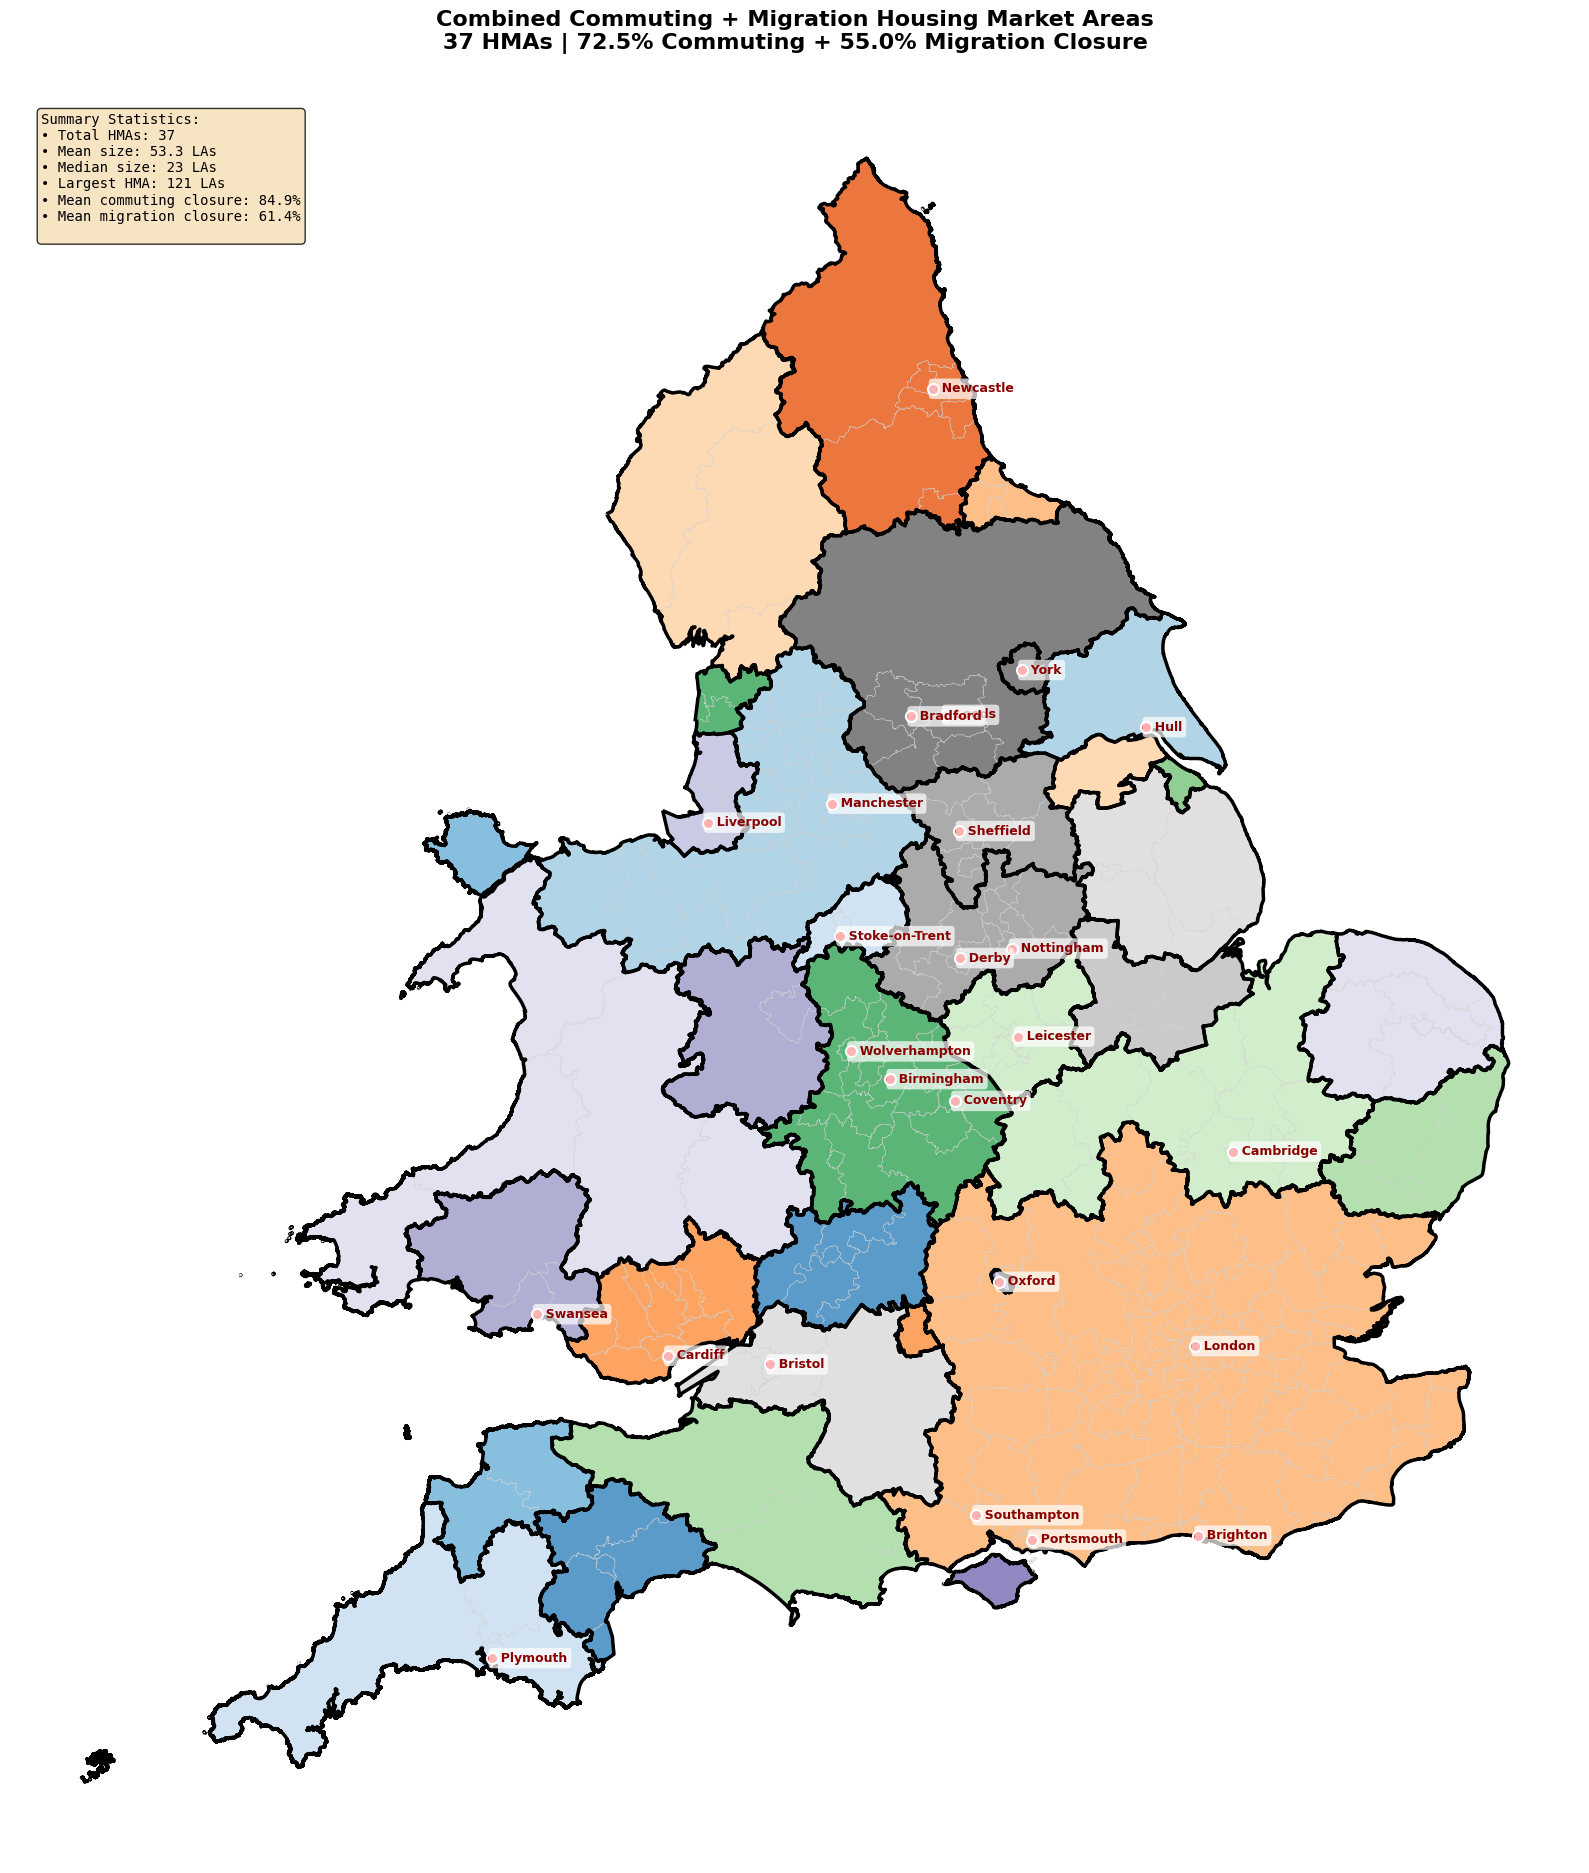

 Map created showing 37 housing market areas with 25 major cities


In [17]:
# Merge HMA data with geographic data
gdf_hma = gdf_la_2023.merge(combined_hma_df, on='LAD23CD', how='left')

# Dissolve geometries by HMA_ID to create single polygons for each region
gdf_hma_dissolved = gdf_hma.dissolve(by='HMA_ID', aggfunc='first')

# Create a colormap with distinct colors
n_hmas = len(gdf_hma_dissolved)
colors = plt.cm.tab20c(np.linspace(0, 1, n_hmas))
np.random.seed(42)
np.random.shuffle(colors)  # Shuffle to avoid adjacent areas having similar colors

# Major cities in England and Wales (lon, lat in WGS84)
major_cities_wgs84 = {
    'London': (-0.1276, 51.5074),
    'Birmingham': (-1.8904, 52.4862),
    'Manchester': (-2.2426, 53.4808),
    'Leeds': (-1.5491, 53.8008),
    'Liverpool': (-2.9916, 53.4084),
    'Sheffield': (-1.4701, 53.3811),
    'Bristol': (-2.5879, 51.4545),
    'Newcastle': (-1.6178, 54.9783),
    'Nottingham': (-1.1581, 52.9548),
    'Southampton': (-1.4044, 50.9097),
    'Cardiff': (-3.1791, 51.4816),
    'Leicester': (-1.1332, 52.6369),
    'Coventry': (-1.5086, 52.4068),
    'Bradford': (-1.7594, 53.7960),
    'Swansea': (-3.9436, 51.6214),
    'Plymouth': (-4.1427, 50.3755),
    'Portsmouth': (-1.0880, 50.8198),
    'Derby': (-1.4746, 52.9225),
    'Wolverhampton': (-2.1234, 52.5864),
    'Stoke-on-Trent': (-2.1894, 53.0027),
    'Hull': (-0.3274, 53.7457),
    'York': (-1.0803, 53.9600),
    'Oxford': (-1.2577, 51.7520),
    'Cambridge': (0.1218, 52.2053),
    'Brighton': (-0.1372, 50.8225)
}

# Convert city coordinates from WGS84 to British National Grid (EPSG:27700)
city_data = []
for city, (lon, lat) in major_cities_wgs84.items():
    city_data.append({'city': city, 'geometry': Point(lon, lat)})

cities_gdf = gpd.GeoDataFrame(city_data, crs='EPSG:4326')
cities_gdf = cities_gdf.to_crs('EPSG:27700')

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(16, 20))

# First layer: Plot individual LAs with soft boundaries
gdf_hma.plot(
    column='HMA_ID',
    ax=ax,
    cmap=ListedColormap(colors),
    edgecolor='lightgray',
    linewidth=0.4,
    legend=False,
    alpha=0.8
)

# Second layer: Plot the dissolved HMA regions with bold borders (no fill)
gdf_hma_dissolved.boundary.plot(
    ax=ax,
    edgecolor='black',
    linewidth=2.5
)

# Add major cities using converted coordinates
for idx, row in cities_gdf.iterrows():
    x, y = row.geometry.x, row.geometry.y
    city_name = row['city']
    
    # Plot city marker
    ax.plot(x, y, 'o', color='red', markersize=8, markeredgecolor='white', 
            markeredgewidth=1.5, zorder=10)
    # Add city label
    ax.text(x, y, f'  {city_name}', fontsize=9, fontweight='bold', 
            verticalalignment='center', color='darkred', zorder=11,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))

# Add title with statistics
title = f'Combined Commuting + Migration Housing Market Areas\n'
title += f'{len(final_hmas)} HMAs | {COMMUTING_THRESHOLD:.1%} Commuting + {MIGRATION_THRESHOLD:.1%} Migration Closure'
ax.set_title(title, fontsize=16, fontweight='bold', pad=20)

# Remove axis
ax.axis('off')

# Add statistics box
stats_text = f"""Summary Statistics:
• Total HMAs: {len(final_hmas)}
• Mean size: {combined_hma_df['HMA_Size'].mean():.1f} LAs
• Median size: {combined_hma_df['HMA_Size'].median():.0f} LAs
• Largest HMA: {combined_hma_df['HMA_Size'].max()} LAs
• Mean commuting closure: {combined_hma_df.groupby('HMA_ID')['Commuting_SC'].first().mean():.1%}
• Mean migration closure: {combined_hma_df.groupby('HMA_ID')['Migration_SC'].first().mean():.1%}
"""

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props, family='monospace')

plt.tight_layout()
plt.show()

print(f" Map created showing {len(final_hmas)} housing market areas with 25 major cities")

In [18]:
gdf_hma

,LAD23CD,LAD23NM,LAD23NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry,HMA_ID,HMA_Name,HMA_Size,Commuting_SC,Migration_SC
0,E06000001,Hartlepool,None,447160,531474,-1.27018,54.6761,625a5484-2e3b-48e6-9432-f8fe739d51ae,"POLYGON ((447213.9 537036.104, 447228.798 5370...",19,R_259,4,0.855958,0.704019
1,E06000002,Middlesbrough,None,451141,516887,-1.21099,54.5447,8572b446-af6a-4051-9859-84f50367cad3,"POLYGON ((448489.897 522071.798, 448592.597 52...",19,R_259,4,0.855958,0.704019
2,E06000003,Redcar and Cleveland,None,464361,519597,-1.00608,54.5675,1171253c-2518-45d6-a4ba-79f76338dfe9,"POLYGON ((455525.931 528406.654, 455724.632 52...",19,R_259,4,0.855958,0.704019
3,E06000004,Stockton-on-Tees,None,444940,518183,-1.30664,54.5569,57c594d8-b705-4381-8776-28169aab47f1,"POLYGON ((444157.002 527956.304, 444165.898 52...",19,R_259,4,0.855958,0.704019
4,E06000005,Darlington,None,428029,515648,-1.56835,54.5353,4667f710-73b3-4c7b-9fb3-49f13e330016,"POLYGON ((423496.602 524724.299, 423497.204 52...",10,R_223,8,0.943606,0.785616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313,W06000020,Torfaen,Torfaen,327459,200480,-3.05101,51.6984,601b146e-f478-44ed-ac5e-3eb89ac3fe66,"POLYGON ((323898.201 211287.499, 324115.698 21...",14,R_248,10,0.923996,0.727393
314,W06000021,Monmouthshire,Sir Fynwy,337812,209231,-2.90280,51.7783,7f44d5eb-d9eb-47eb-96c4-50982d1c8dd7,"MULTIPOLYGON (((345965.201 181030.7, 345944.14...",14,R_248,10,0.923996,0.727393
315,W06000022,Newport,Casnewydd,337897,187432,-2.89769,51.5823,5f161be6-a8f7-45c3-b25c-b5f2dd6daa3e,"POLYGON ((342211.9 194845.495, 342221.803 1948...",14,R_248,10,0.923996,0.727393
316,W06000023,Powys,Powys,302329,273255,-3.43531,52.3486,952dbaa1-c177-466e-bf98-3f08de6aacba,"POLYGON ((322392.901 334017.198, 322378.002 33...",36,M_20,5,0.838492,0.515695
